In [13]:
import pandas as pd
import plotly.express as px

df = px.data.gapminder()

df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [19]:
print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

# Task 1

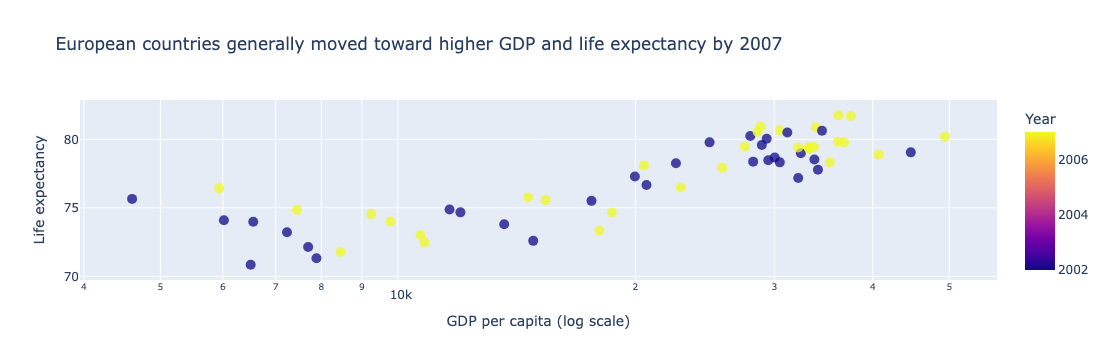

In [25]:

continent_choice = "Europe"

task1_df = df.loc[
    (df["continent"] == continent_choice) &
    (df["year"].isin([2002, 2007]))
].copy()

fig = px.scatter(
    task1_df,
    x="gdpPercap",
    y="lifeExp",
    color="year",
    hover_name="country",
    log_x=True,
    title="European countries generally moved toward higher GDP and life expectancy by 2007",
    labels={
        "gdpPercap": "GDP per capita (log scale)",
        "lifeExp": "Life expectancy",
        "year": "Year"
    }
)

fig.update_traces(marker=dict(size=10, opacity=0.75))

fig.show()

# Task 2

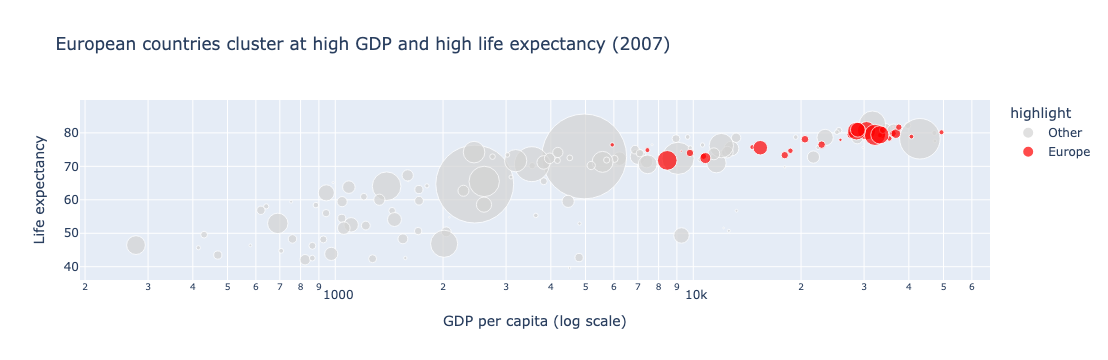

In [52]:

# 2007 verisi
df_2007 = df[df['year'] == 2007].copy()

# 2. Highlight için 
highlight_continent = "Europe"  

df_2007['highlight'] = df_2007['continent'].apply(
    lambda x: highlight_continent if x == highlight_continent else 'Other'
)

# 3. Bubble chart part
fig = px.scatter(
    df_2007,
    x='gdpPercap',
    y='lifeExp',
    size='pop',
    color='highlight',
    hover_name='country',
    log_x=True,
    size_max=60,
    color_discrete_map={
        highlight_continent: 'red',
        'Other': 'lightgrey'
    },
    title= 'European countries cluster at high GDP and high life expectancy (2007)',
    labels={
        'gdpPercap': 'GDP per capita (log scale)',
        'lifeExp': 'Life expectancy'
    }
)

# 4. Annotation - story part
fig.add_annotation(
    x=20000,
    y=75,
    text=f"{highlight_continent} countries show strong economic performance and high life expectancy",
    showarrow=True
)

fig.show()